Monte um script em python para determinar uma regressão usando Regressão Linear Multipla.
Use cross validation para a seleção dos melhores grupos de teste e treino.
Use grid search para determinação de hiperparâmetros
Uma das variáveis do banco é nominal, inclua no Pepiline a função one_hot_encoder

# Importando Bibliotecas

In [1]:
# Seleção de diretórios
import os
try:
    # Configurando diretório de trabalho para 'aulas_teoricas'
    os.chdir('aulas_teoricas')
except FileNotFoundError:
    pass

# Carregamento de dados
from joblib import load, dump

# Processamento de dados
import numpy as np
import pandas as pd
from util import utils as ut

# Graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Classificador 
from src.classifier import Classifier

# Importando Dados

In [2]:
# Verificando os arquivos no diretório 'data/df_estruturada'
os.listdir("./data/df_estruturada")

['08_aula_09_X_test',
 '08_aula_09_X_train',
 '08_aula_09_X_valid',
 '08_aula_09_y_test',
 '08_aula_09_y_train',
 '08_aula_09_y_valid']

In [3]:
# Importando os dados de treino
df_train = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_train"),
    load("./data/df_estruturada/08_aula_09_y_train")
], axis=1)
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Alterado,imunodeficiencia
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Alterado,imunodeficiencia
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Normal,leucemia
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Alterado,imunodeficiencia
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Normal,leucemia


In [4]:
# Importando os dados de treino
df_valid = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_valid"),
    load("./data/df_estruturada/08_aula_09_y_valid")
], axis=1)
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Alterado,imunodeficiencia
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Normal,leucemia
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Normal,cancer
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Normal,cancer
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Normal,cancer


In [5]:
# Importando os dados de treino
df_test = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_test"),
    load("./data/df_estruturada/08_aula_09_y_test")
], axis=1)
df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Normal,cancer
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Normal,leucemia
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Normal,cancer
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Normal,cancer
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Alterado,imunodeficiencia


# Validação cruzada e busca de hiperparâmetros

## K-NN

### Treino

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Melhor acurácia (CV): 0.7686

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8429



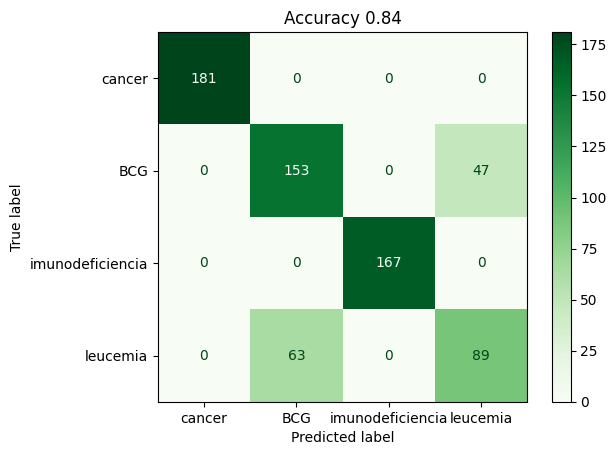


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.71      0.77      0.74       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.65      0.59      0.62       152

        accuracy                           0.84       700
       macro avg       0.84      0.84      0.84       700
    weighted avg       0.84      0.84      0.84       700



In [6]:
classificador = Classifier(
    df=df_train
)
classificador.classify(modelo='knn')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Melhor acurácia (CV): 0.7829

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.7829



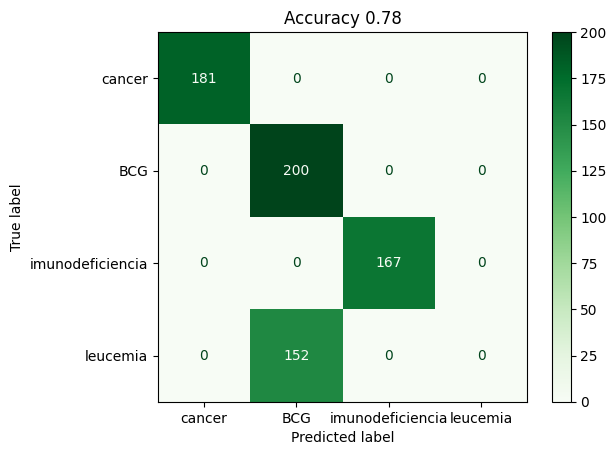


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.57      1.00      0.72       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.00      0.00      0.00       152

        accuracy                           0.78       700
       macro avg       0.64      0.75      0.68       700
    weighted avg       0.66      0.78      0.70       700



/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
classificador.classify(modelo='svm')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'rf__criterion': 'gini', 'rf__max_depth': 5, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Melhor acurácia (CV): 0.7871

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8257



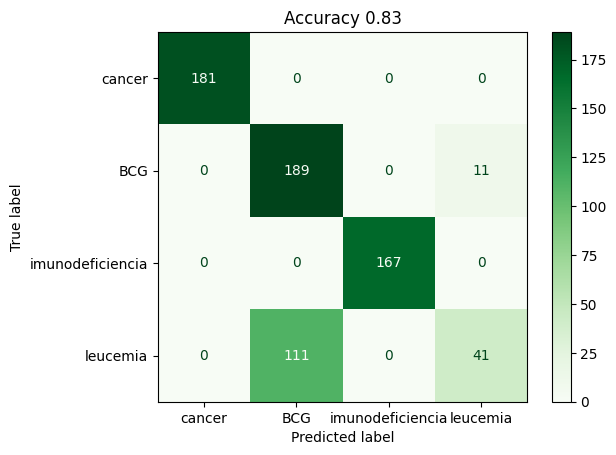


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.63      0.94      0.76       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.79      0.27      0.40       152

        accuracy                           0.83       700
       macro avg       0.85      0.80      0.79       700
    weighted avg       0.85      0.83      0.80       700



In [8]:
classificador.classify(modelo='rf')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'gb__learning_rate': 0.01, 'gb__max_depth': 3, 'gb__n_estimators': 50, 'gb__subsample': 0.8}
Melhor acurácia (CV): 0.7728

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8029



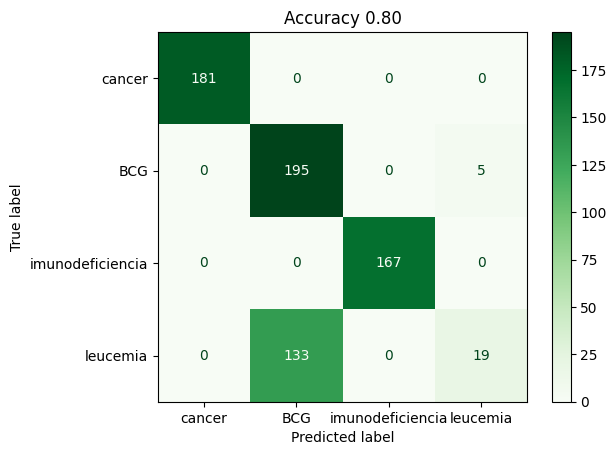


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.59      0.97      0.74       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.79      0.12      0.22       152

        accuracy                           0.80       700
       macro avg       0.85      0.78      0.74       700
    weighted avg       0.84      0.80      0.76       700



In [9]:
classificador.classify(modelo='gbm')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'nb__var_smoothing': 1.0}
Melhor acurácia (CV): 0.7829

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.7829



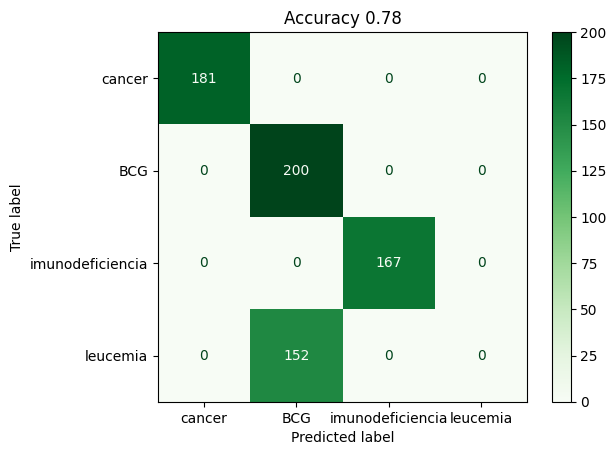


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.57      1.00      0.72       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.00      0.00      0.00       152

        accuracy                           0.78       700
       macro avg       0.64      0.75      0.68       700
    weighted avg       0.66      0.78      0.70       700



/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
classificador.classify(modelo='nb')

--- Treinando modelo com Pipeline de pré-processamento ---


/usr/local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS R


--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'mlp__activation': 'tanh', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (20, 10), 'mlp__solver': 'lbfgs'}
Melhor acurácia (CV): 0.7700

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8614



/usr/local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS R

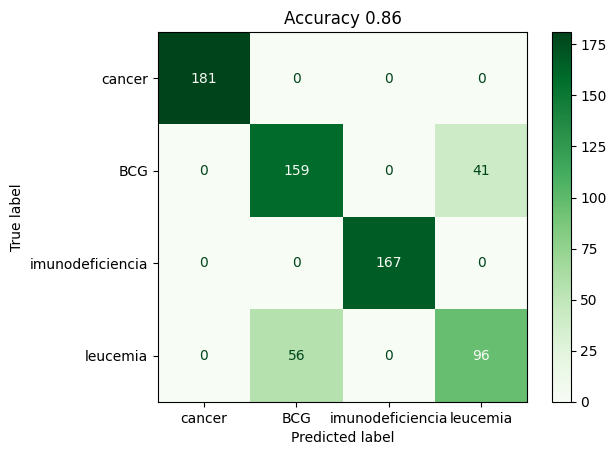


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.74      0.80      0.77       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.70      0.63      0.66       152

        accuracy                           0.86       700
       macro avg       0.86      0.86      0.86       700
    weighted avg       0.86      0.86      0.86       700



In [11]:
classificador.classify(modelo='nn')

### Validação

### Teste

# Avalia Modelos